## Background
The Netflix Top 10 charts represent the most popular movies and TV series, with millions of viewers around the globe. Understanding what makes the biggest hits is crucial to making more hits.

## Challenge
Explore the dataset to understand the most common attributes of popular Netflix content. Your published notebook should contain a short report on the popular content, including summary statistics, visualizations, statistical models, and text describing any insights you found.

## The data
There are three datasets taken.
- `all-weeks-global-netflix`: This contains the weekly top 10 list for movies (films) and TV series at a global level.
- `all-weeks-countries-netflix`: This contains the weekly top 10 list for movies (films) and TV series by country.
- `most-popular-netflix`: All-time most popular content by number of hours viewed in the first 28 days from launch.

In [32]:
# Importing the packages and libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates
from wordcloud import WordCloud
import datetime as dt


In [33]:
# Load the three Netflix datasets

global_df = pd.read_csv('./all-weeks-global-netflix.csv')
popular_df = pd.read_csv('./most-popular-netflix.csv')
countries_df = pd.read_csv('./all-weeks-countries-netflix.csv')


# Top Weekly Global Movies on Netflix 

In [34]:
# create a dataframe named named world from all_weeks_global postgresql table
world  = global_df
world.head(5)

,week,category,weekly_rank,show_title,season_title,weekly_hours_viewed,runtime,weekly_views,cumulative_weeks_in_top_10,is_staggered_launch,episode_launch_details
0,2024-04-14,Films (English),1,What Jennifer Did,NaN,26100000,1.4500,18000000.0,1,False,NaN
1,2024-04-14,Films (English),2,Woody Woodpecker Goes to Camp,NaN,19600000,1.6667,11800000.0,1,False,NaN
2,2024-04-14,Films (English),3,Scoop,NaN,14600000,1.7167,8500000.0,2,False,NaN
3,2024-04-14,Films (English),4,Glass,NaN,11000000,2.1500,5100000.0,2,False,NaN
4,2024-04-14,Films (English),5,Megan Leavey,NaN,9700000,1.9333,5000000.0,1,False,NaN


In [35]:
# find the total number of rows and columns

world.shape

(5840, 11)

In [36]:
# any missing values?

world.isna().sum()

week                             0
category                         0
weekly_rank                      0
show_title                       0
season_title                  3026
weekly_hours_viewed              0
runtime                       4080
weekly_views                  4080
cumulative_weeks_in_top_10       0
is_staggered_launch              0
episode_launch_details        5768
dtype: int64

In [37]:
# dropping missing values

world.dropna(inplace = True)

In [38]:
# display max number of rows
pd.set_option('display.max_rows', None)

world.dtypes

week                           object
category                       object
weekly_rank                     int64
show_title                     object
season_title                   object
weekly_hours_viewed             int64
runtime                       float64
weekly_views                  float64
cumulative_weeks_in_top_10      int64
is_staggered_launch              bool
episode_launch_details         object
dtype: object

In [39]:
# changing datatype of week to datetime
world['week'] = world['week'].apply(pd.to_datetime)

In [40]:
pd.set_option('display.max_rows', None)

world.dtypes

week                          datetime64[ns]
category                              object
weekly_rank                            int64
show_title                            object
season_title                          object
weekly_hours_viewed                    int64
runtime                              float64
weekly_views                         float64
cumulative_weeks_in_top_10             int64
is_staggered_launch                     bool
episode_launch_details                object
dtype: object

In [41]:
# Checking min and max date of data
print(world.week.min())
print(world.week.max())

2023-06-18 00:00:00
2024-04-14 00:00:00


In [42]:
len(world.week.value_counts())

40

## This data was derived for over a period of 40 weeks (280 days) from 2023-06-18 to 2024-04-14

## Most watched category  worldwide in descending order

In [43]:
world.groupby(['category'])['weekly_hours_viewed'].mean().round().sort_values(ascending = False).reset_index()

,category,weekly_hours_viewed
0,TV (Non-English),22707576.0
1,TV (English),21066667.0


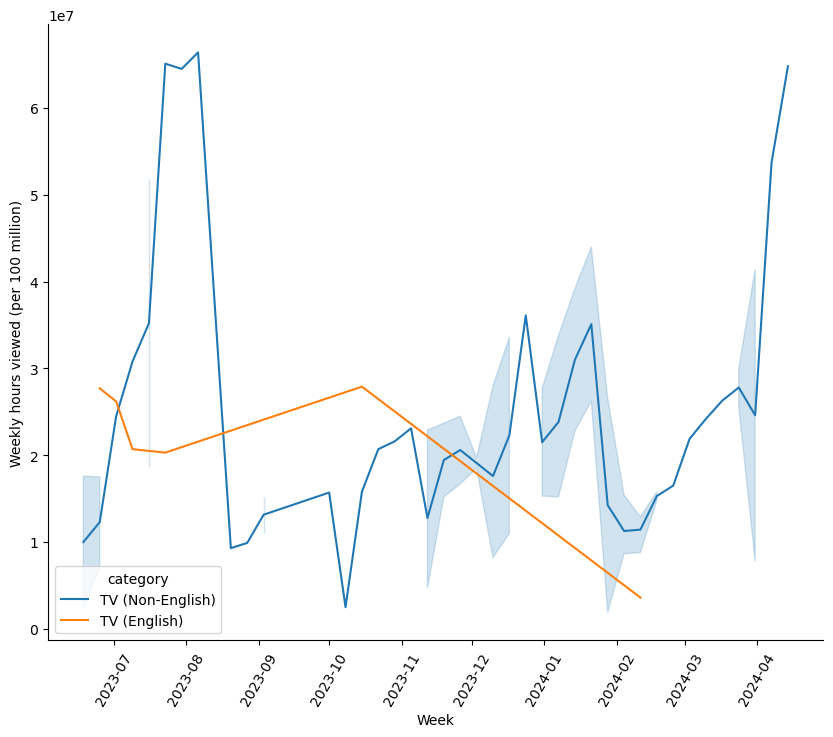

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure (figsize = (10,8))
sns.lineplot(x='week', y = 'weekly_hours_viewed', hue = 'category',  data = world)
plt.ylabel('Weekly hours viewed (per 100 million)')
plt.xlabel ('Week')
plt.xticks (rotation = 60)
sns.despine()

### From the table and graph depicted above, the top most viewed categories in descending order are 
1. TV (English) 
2. TV (Non-English)
3. Films (English) 
3. Films (Non-English) 

## Top 10 TV shows with the most weekly hours viewed worldwide

In [45]:
top_TV_shows = world.groupby(['season_title', 'category'])['weekly_hours_viewed'].mean().round().sort_values(ascending = False)[:10]
top_TV_shows = top_TV_shows.reset_index()
top_TV_shows

,season_title,category,weekly_hours_viewed
0,Queen of Tears: Limited Series,TV (Non-English),47475000.0
1,King the Land: Limited Series,TV (Non-English),40375000.0
2,My Demon: Limited Series,TV (Non-English),32762500.0
3,Love Is Blind: Season 5,TV (English),27900000.0
4,Suits: Season 1,TV (English),23725000.0
5,Strong Girl Nam-soon: Limited Series,TV (Non-English),19350000.0
6,Welcome to Samdal-ri: Limited Series,TV (Non-English),18775000.0
7,Record of Ragnarok: Season 2,TV (Non-English),18600000.0
8,The Good Bad Mother: Limited Series,TV (Non-English),17600000.0
9,Doctor Slump: Limited Series,TV (Non-English),17144444.0


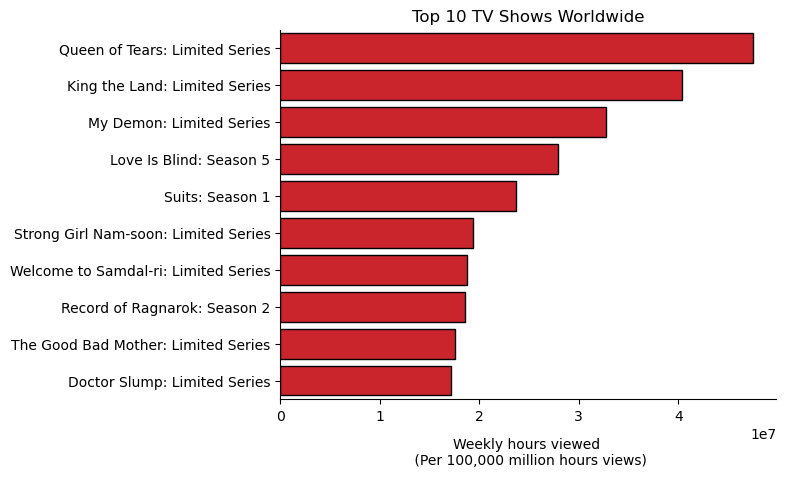

In [46]:
# Bar graph of top 10 shows on basis of views
sns.barplot(y = 'season_title', x = 'weekly_hours_viewed', color = '#E50914',edgecolor = 'black', data = top_TV_shows)
plt.title('Top 10 TV Shows Worldwide')
plt.xlabel('Weekly hours viewed \n (Per 100,000 million hours views)', labelpad = 10)
plt.ylabel('')
sns.despine()

### The above findings so far are quite interesting: 8 out of the top 10 shows were Non English TV shows while only 2 (Love is Blind and Suits) were a English TV show.
### It appears that globally, mankind prefers watching Non English TV shows.

## Average cumulative weeks in top 10 for the most popular TV shows

In [47]:
season = world[world.season_title.isin(top_TV_shows.season_title.values)]
cum = season.groupby('season_title')['cumulative_weeks_in_top_10'].mean().sort_values(ascending = False)
cum = cum.reset_index()
cum

,season_title,cumulative_weeks_in_top_10
0,The Good Bad Mother: Limited Series,7.0
1,My Demon: Limited Series,5.5
2,Doctor Slump: Limited Series,5.0
3,King the Land: Limited Series,4.5
4,Queen of Tears: Limited Series,4.5
5,Strong Girl Nam-soon: Limited Series,4.5
6,Welcome to Samdal-ri: Limited Series,4.5
7,Love Is Blind: Season 5,4.0
8,Record of Ragnarok: Season 2,3.0
9,Suits: Season 1,2.5


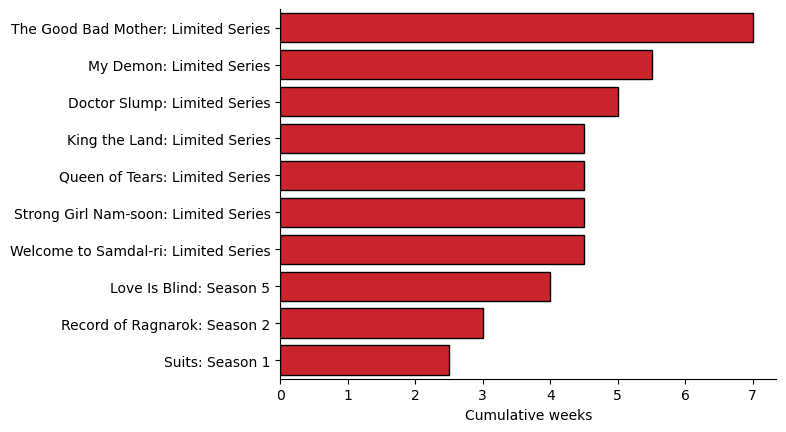

In [48]:
sns.barplot(y = 'season_title' , x = 'cumulative_weeks_in_top_10', color = '#E50914', 
            edgecolor = 'black', data = cum)
plt.ylabel('')
plt.xlabel('Cumulative weeks')
sns.despine()

### Out of the top 10 most watched shows worldwide, the show with the highest cumulative weeks as one of the top 10 watched show is The Good Bad Mother: Limited Series with an average of 7.0 weeks which is fascinating particularly since Queen of Tears: Limited Series which is the most watched show had only 4.5 cumulative weeks and My Demon still in the game with second highest.

In [49]:
popular_df.head(5)

,category,rank,show_title,season_title,hours_viewed_first_91_days,runtime,views_first_91_days
0,Films (English),1,Red Notice,NaN,454200000,1.9667,230900000
1,Films (English),2,Don't Look Up,NaN,408600000,2.3833,171400000
2,Films (English),3,The Adam Project,NaN,281000000,1.7833,157600000
3,Films (English),4,Bird Box,NaN,325300000,2.0667,157400000
4,Films (English),5,Leave the World Behind,NaN,339300000,2.3667,143400000


In [50]:
countries_df.head(5)

,country_name,country_iso2,week,category,weekly_rank,show_title,season_title,cumulative_weeks_in_top_10
0,Argentina,AR,2024-04-14,Films,1,The Tearsmith,NaN,2
1,Argentina,AR,2024-04-14,Films,2,Stolen,NaN,1
2,Argentina,AR,2024-04-14,Films,3,"Love, Divided",NaN,1
3,Argentina,AR,2024-04-14,Films,4,Woody Woodpecker Goes to Camp,NaN,1
4,Argentina,AR,2024-04-14,Films,5,Rest In Peace,NaN,3


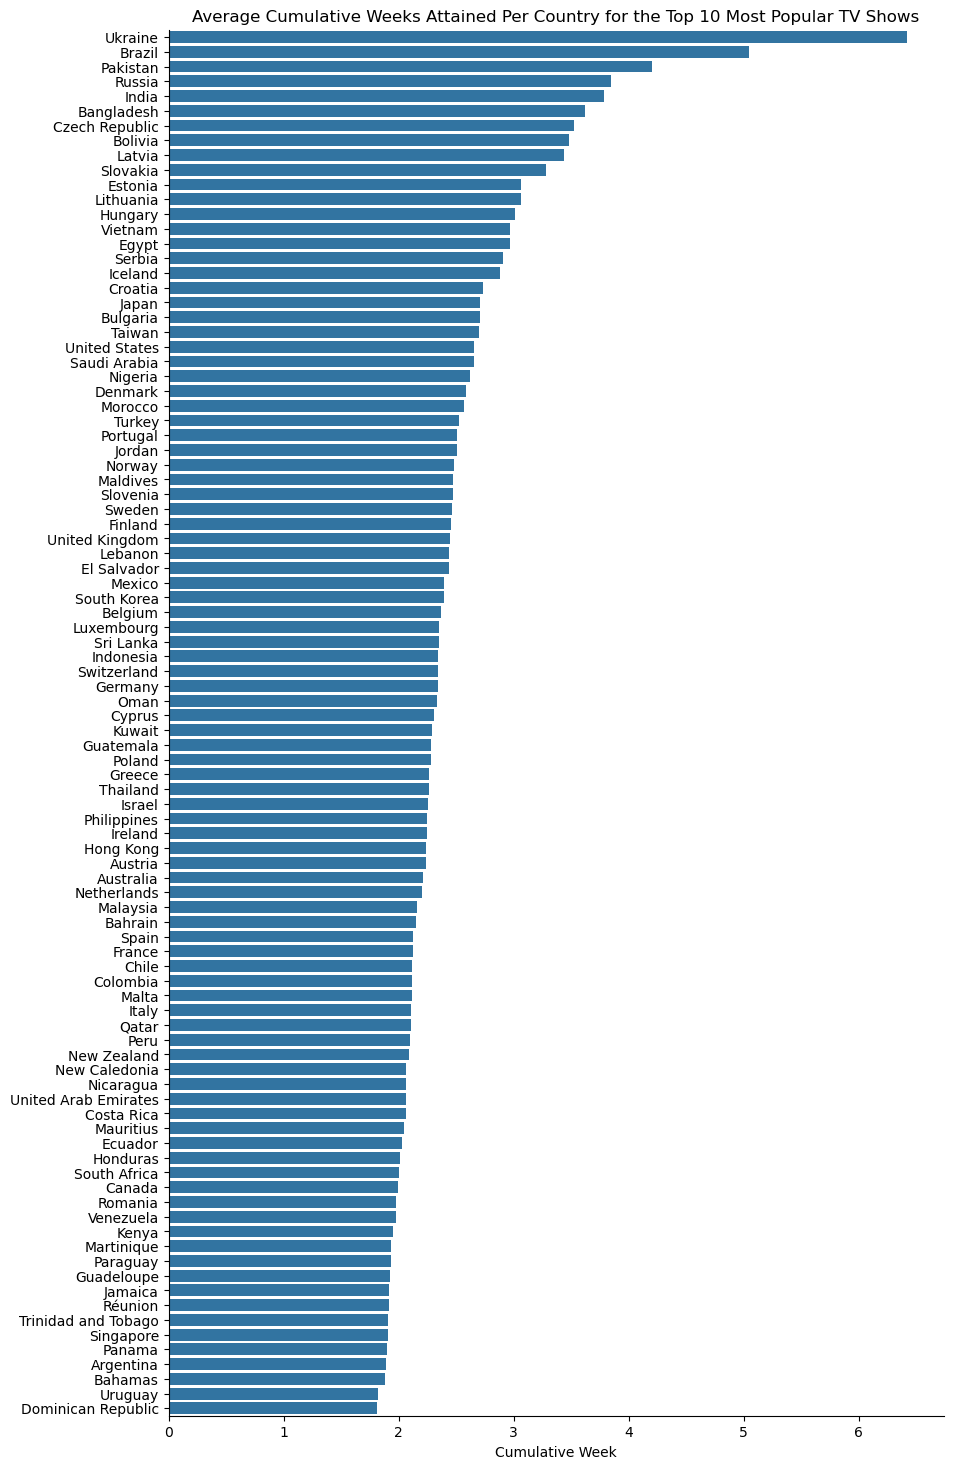

In [51]:
#select the rows with the top 10 most popular TV shows 

country_most_popular_TV = countries_df[countries_df.season_title.isin(popular_df.season_title.values)]

plt.figure (figsize = (10,18))
sns.barplot(x = 'cumulative_weeks_in_top_10', y = 'country_name', data = country_most_popular_TV.groupby('country_name')['cumulative_weeks_in_top_10'].mean().sort_values( ascending = False).reset_index())
plt.title('Average Cumulative Weeks Attained Per Country for the Top 10 Most Popular TV Shows')
plt.ylabel('')
plt.xlabel ('Cumulative Week')
sns.despine()

### It appears that the top 10 countries that enjoyed the top 10 most popular TV shows the most were 
1. Ukraine
2. Brazil
3. Pakistan
4. Russia
5. India
6. Bangladesh
7. CZech Republic
8. Bolivia
9. Latvia
10. Slovakia

### While the countries that barely watched the top 10 most popular TV shows were 
1. Guadeloupe
2. Jamaica
3. Reunion
4. Trinidad and tobago
5. Singapore
6. Panama
7. Argentina
8. Bahamas
9. Uruguay
10. Dominican Republic

## Which TV show performed best per country?

In [52]:
country_most_popular_TV = countries_df[countries_df.season_title.isin(popular_df.season_title.values)]
final_TV = country_most_popular_TV.groupby(['country_name','season_title'])[['weekly_rank','cumulative_weeks_in_top_10']].mean().round()
final_TV = final_TV.reset_index()
final_TV.sort_values(['cumulative_weeks_in_top_10'], ascending = [False]).reset_index(drop=True)

,country_name,season_title,weekly_rank,cumulative_weeks_in_top_10
0,Ukraine,Lupin: Part 1,6.0,18.0
1,Czech Republic,Wednesday: Season 1,5.0,18.0
2,India,Squid Game: Season 1,5.0,16.0
3,Pakistan,Wednesday: Season 1,5.0,16.0
4,Ukraine,Bridgerton: Season 2,6.0,16.0
5,Pakistan,Money Heist: Part 3,8.0,16.0
6,Ukraine,The Night Agent: Season 1,6.0,14.0
7,Pakistan,Money Heist: Part 5,6.0,14.0
8,India,All of Us Are Dead: Season 1,6.0,14.0
9,Ukraine,Wednesday: Season 1,5.0,14.0


In [53]:
# This list cointains the TV shows which is most popular country wise

## And this concludes my review. Non English TV shows were very popular globally but one TV show Good Bad Mother really outperformed them all particularly when a standard metric was used.

## The country which spend most time for the top shows are Ukraine, Czech Republic, India, Pakistan whereas Bahamas, Jamica, Trinidad and togobo spend least time for the most popular TV shows

### Thank you